In [39]:
#%%writefile task1_data_collection.py
from numpy import show_runtime
#task1_data_collection.py
import requests
import pandas as pd

def fetch_data():
    url = "https://api.coingecko.com/api/v3/search/trending"
    response = requests.get(url)
    data = response.json()

    coins = data['coins']

    coin_list = []
    for coin in coins:
        item = coin['item']
        coin_list.append({
            "name": item['name'],
            "symbol": item['symbol'],
            "market_cap_rank": item['market_cap_rank'],
            "price_btc": item['price_btc']
        })

    df = pd.DataFrame(coin_list)
    df.to_csv("trending_coins_raw.csv", index=False)
    print("Data collected and saved!")

if __name__ == "__main__":
    fetch_data()

Data collected and saved!


fetch_data() function:
It defines the API endpoint for CoinGecko's trending cryptocurrencies.
It sends a GET request to this URL and parses the JSON response.
It then extracts a list of 'coins' from the response.
For each coin, it extracts key details like name, symbol, market_cap_rank, and price_btc, organizing them into a list of dictionaries.
Finally, it converts this list into a pandas DataFrame and saves it as trending_coins_raw.csv.
The if __name__ == "__main__": block ensures that the fetch_data() function is called when the script is run directly.

In [40]:
#%%writefile task2_data_processing.py
#Clean and prepare data
import pandas as pd

def clean_data():
    df = pd.read_csv("trending_coins_raw.csv")

    # Handle missing values
    df = df.dropna()

    # Convert data types if needed
    df['market_cap_rank'] = df['market_cap_rank'].astype(int)

    # Sort by rank
    df = df.sort_values(by='market_cap_rank')

    df.to_csv("trending_coins_cleaned.csv", index=False)
    print("Data cleaned and saved!")

if __name__ == "__main__":
    clean_data()

Data cleaned and saved!


**clean_data() function:**
Read CSV: It reads the raw data from trending_coins_raw.csv into a pandas DataFrame.
Handle missing values: df.dropna() removes any rows that contain missing values, ensuring data completeness.
cleaned and sorted DataFrame is saved to a new CSV file named trending_coins_cleaned.csv, without including the DataFrame index.

In [41]:
#%%writefile task3_analysis.py
#Perform analysis
import pandas as pd

def analyze_data():
    df = pd.read_csv("trending_coins_cleaned.csv")

    print("\nTop 5 Coins:")
    print(df.head())

    print("\nAverage Market Rank:")
    print(df['market_cap_rank'].mean())

    print("\nHighest BTC Price Coin:")
    print(df.loc[df['price_btc'].idxmax()])

if __name__ == "__main__":
    analyze_data()


Top 5 Coins:
          name symbol  market_cap_rank  price_btc
0      Bitcoin    BTC                1   1.000000
1     Ethereum    ETH                2   0.031231
2       Solana    SOL                7   0.001232
3  Hyperliquid   HYPE               16   0.000530
4    Bittensor    TAO               33   0.004655

Average Market Rank:
223.26666666666668

Highest BTC Price Coin:
name               Bitcoin
symbol                 BTC
market_cap_rank          1
price_btc              1.0
Name: 0, dtype: object


**Read Cleaned Data**: It first reads the trending_coins_cleaned.csv file into a pandas DataFrame.
**Display Top 5 Coins**: It prints a header 'Top 5 Coins:' and then uses df.head() to display the first 5 rows of the DataFrame, showing the top trending cryptocurrencies by market cap rank.
**Calculate Average Market Rank**: It calculates and prints the average market capitalization rank of all the coins in the DataFrame using df['market_cap_rank'].mean().
**Identify Highest BTC Price Coin**: It finds and prints the coin with the highest 'price_btc' (price in Bitcoin) by using df['price_btc'].idxmax() to get the index of the maximum value, and then df.loc[] to retrieve the full row for that coin.

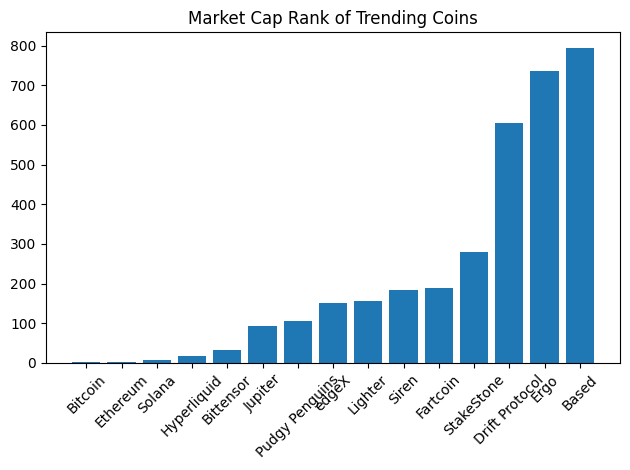

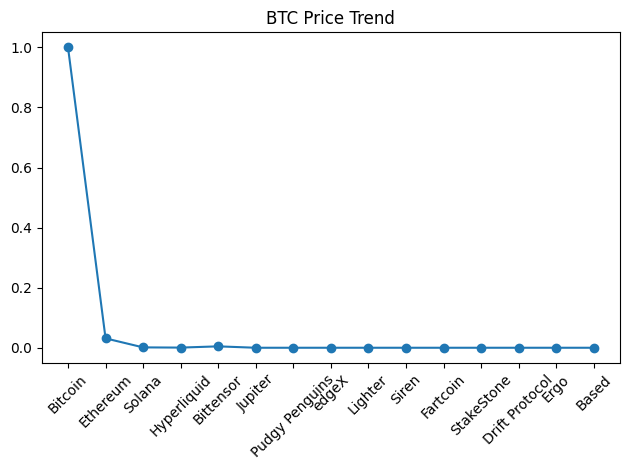

In [42]:
#%%writefile task4_visualization.py
#Visualize trends
import pandas as pd
import matplotlib.pyplot as plt

def visualize_data():
    df = pd.read_csv("trending_coins_cleaned.csv")

    # Bar chart for market rank
    plt.figure()
    plt.bar(df['name'], df['market_cap_rank'])
    plt.title("Market Cap Rank of Trending Coins")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Line chart for BTC price
    plt.figure()
    plt.plot(df['name'], df['price_btc'], marker='o')
    plt.title("BTC Price Trend")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_data()

**plt.figure()**: This command creates a new, empty figure to draw the plot on.
**plt.bar(df['name'], df['market_cap_rank'])**: This is the core of the bar chart. It plots the name of each cryptocurrency (from the DataFrame's 'name' column) on the x-axis and its market_cap_rank (from the 'market_cap_rank' column) on the y-axis.
**plt.titl**e("Market Cap Rank of Trending Coins"): This sets the title for the bar chart, making it clear what the chart represents.
**plt.tight_layout()**: This command automatically adjusts plot parameters for a tight layout

In [35]:
!ls


raw			  task2_data_processing.py  trending_coins_cleaned.csv
sample_data		  task3_analysis.py	    trending_coins_raw.csv
task1_data_collection.py  task4_visualization.py


In [37]:
fetch_data()
!python task1_data_collection.py

!python task2_data_processing.py
!python task3_analysis.py
!python task4_visualization.py

Data collected and saved!
Data collected and saved!
Data cleaned and saved!

Top 5 Coins:
         name symbol  market_cap_rank  price_btc
0     Bitcoin    BTC                1   1.000000
1    Ethereum    ETH                2   0.031308
2      Solana    SOL                7   0.001235
3   Bittensor    TAO               33   0.004677
4  Pi Network     PI               46   0.000003

Average Market Rank:
220.06666666666666

Highest BTC Price Coin:
name               Bitcoin
symbol                 BTC
market_cap_rank          1
price_btc              1.0
Name: 0, dtype: object
Figure(640x480)
Figure(640x480)


In [38]:
from google.colab import files
#Download Files from Colab
files.download("task1_data_collection.py")
files.download("task2_data_processing.py")
files.download("task3_analysis.py")
files.download("task4_visualization.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# New Section

In [29]:
!python task1_data_collection.py

python3: can't open file '/content/task1_data_collection.py': [Errno 2] No such file or directory
